# Anomaly Detection with Gaussian Models

### Machine Learning from Scratch | Research Notebook

---

## Overview

Anomaly detection is a fundamental unsupervised learning task that aims to identify observations that deviate significantly from the expected distribution of data. Unlike traditional supervised classification, anomaly detection often operates in scenarios where anomalous examples are scarce, unavailable, or continuously evolving. As a result, the objective is to model *normal* behavior and flag observations that are statistically unlikely under that model.

This notebook develops a Gaussian-based anomaly detection system from first principles. Rather than relying on high-level machine learning libraries, every major component is implemented step by step to understand the underlying statistical concepts, mathematical derivations, and practical considerations.

---

## Objectives

By the end of this notebook, we will:

- Develop an intuitive understanding of anomaly detection.
- Explore the statistical assumptions behind Gaussian models.
- Estimate Gaussian parameters from data.
- Compute probability densities for unseen observations.
- Learn how to select an optimal decision threshold using validation data.
- Evaluate anomaly detection performance using Precision, Recall, and F1 Score.
- Investigate the strengths and limitations of Gaussian-based anomaly detection through experiments.

---

## Topics Covered

1. Introduction to Anomaly Detection
2. Problem Formulation
3. Statistical Foundations (Gaussian Distribution, MLE, Parameter Estimation)
4. Dataset Exploration
5. Estimating Gaussian Parameters
6. Probability Density Estimation
7. Threshold Selection and Evaluation Metrics
8. Discussion
9. Limitations and Future Directions
10. Conclusion

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal

# Plot configuration
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 11

# Reproducibility
np.random.seed(42)

# 1. Introduction to Anomaly Detection

Anomaly detection is the task of identifying observations that differ significantly from the majority of the data. These unusual observations, commonly referred to as **anomalies**, **outliers**, or **novel instances**, often represent rare but important events that require further investigation.

Unlike traditional supervised classification, anomaly detection is typically performed in situations where labeled anomalous examples are scarce or unavailable. Instead of learning the characteristics of every possible abnormal event, the model learns the statistical properties of **normal data** and identifies observations that deviate from this learned behavior.

The underlying assumption is that normal observations occur frequently and follow a predictable distribution, whereas anomalous observations are rare and have a low probability of being generated by that same distribution.

---

## Why is Anomaly Detection Important?

Many real-world systems operate under normal conditions for the vast majority of the time. Abnormal events are uncommon but often carry significant consequences. Detecting these rare events early can improve reliability, reduce costs, and enhance security.

Some common applications include:

- **Financial Fraud Detection:** Identifying suspicious credit card or banking transactions.
- **Cybersecurity:** Detecting unusual network traffic, malware activity, or unauthorized access.
- **Manufacturing:** Discovering defective products during quality control.
- **Healthcare:** Detecting abnormal patient vital signs or medical conditions.
- **Predictive Maintenance:** Identifying machine failures before they occur.
- **Cloud Infrastructure Monitoring:** Detecting unexpected server behavior or performance degradation.

Although the domains differ, the central objective remains the same: distinguish normal observations from those that are statistically unlikely.

# 2. Problem Formulation

Suppose we are given a dataset consisting primarily of normal observations,

$$
X = \{x^{(1)}, x^{(2)}, \ldots, x^{(m)}\},
$$

where each observation

$$
x^{(i)} \in \mathbb{R}^{n}
$$

contains **\(n\)** numerical features.

Our objective is to estimate the probability that a new observation was generated from the same distribution as the training data.

Mathematically, we seek to estimate

$$
P(x).
$$

If an observation has a sufficiently low probability of occurring under the learned distribution, it is considered an anomaly.

This decision can be expressed using a threshold parameter, denoted by $$\varepsilon$$:

$$
P(x) < \varepsilon
\Longrightarrow
x \text{ is classified as an anomaly.}
$$

Otherwise,

$$
P(x) \ge \varepsilon,
$$

the observation is treated as normal.

---

The success of this approach depends on two key components:

1. **Accurately modeling the distribution of normal data.**
2. **Selecting an appropriate decision threshold ($$\varepsilon$$).**

Throughout this notebook, we will construct both components using Gaussian probability distributions and evaluate their effectiveness through experiments.

# 3. Statistical Foundations

To determine whether an observation is anomalous, we first need a mathematical model that describes the distribution of **normal data**. One of the most widely used statistical models for this purpose is the **Gaussian (Normal) Distribution**.

The Gaussian distribution assumes that most observations are concentrated around a central value (the mean), while observations become increasingly less likely as they move farther away from this center.

This assumption is surprisingly effective for many naturally occurring phenomena due to the **Central Limit Theorem**, which states that the sum (or average) of many independent random variables tends toward a normal distribution under fairly general conditions.

A Gaussian model is characterized by two parameters:

- **Mean ($$\mu$$):** Represents the center of the distribution.
- **Variance ($$\sigma^2$$):** Measures the spread or dispersion of the data.

Together, these parameters define the shape of the probability distribution and allow us to estimate how likely a new observation is to occur.

In anomaly detection, observations that lie in regions of **very low probability density** are considered potential anomalies because they are unlikely to have been generated by the same underlying distribution as the majority of the data.

# 3.1 Gaussian Distribution

A one-dimensional Gaussian distribution is defined by its probability density function (PDF):

$$
p(x)=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right)
$$

where

- $x$ is the observation.
- $\mu$ is the mean of the distribution.
- $\sigma^2$ is the variance.
- $\sigma$ is the standard deviation, where

$$
\sigma=\sqrt{\sigma^2}.
$$

The Gaussian distribution has several important properties:

- It is symmetric about the mean.
- The highest probability density occurs at $\mu$.
- Probability density decreases smoothly as the distance from the mean increases.
- The total area under the curve is equal to **1**, making it a valid probability distribution.

These properties make the Gaussian distribution a natural choice for modeling normal behavior. Once the parameters $\mu$ and $\sigma^2$ have been estimated from the training data, we can compute the probability density of any new observation and determine whether it should be classified as normal or anomalous.

# 3.2 Maximum Likelihood Estimation (MLE)

The Gaussian distribution is completely determined by two unknown parameters:

- The mean, $$\mu$$
- The variance, $$\sigma^2$$

Since these parameters are not known beforehand, they must be estimated from the available training data.

One of the most common approaches is **Maximum Likelihood Estimation (MLE)**. The core idea of MLE is to choose the parameter values that maximize the probability (likelihood) of observing the given dataset.

Suppose we have a dataset containing $$m$$ independent observations,

$$
X = \{x^{(1)}, x^{(2)}, \ldots, x^{(m)}\}.
$$

Assuming each observation follows a Gaussian distribution, the likelihood of the dataset is

$$
L(\mu,\sigma^2)
=
\prod_{i=1}^{m}
p(x^{(i)};\mu,\sigma^2).
$$

Rather than maximizing this product directly, we maximize its logarithm, known as the **log-likelihood**, since logarithms convert products into sums and simplify differentiation.

After differentiating with respect to the parameters and setting the derivatives equal to zero, the maximum likelihood estimates are obtained.

# 3.3 Estimating the Gaussian Parameters

Applying Maximum Likelihood Estimation yields simple closed-form expressions for the Gaussian parameters.

### Mean

The mean represents the center of the distribution and is computed as

$$
\mu
=
\frac{1}{m}
\sum_{i=1}^{m}
x^{(i)}.
$$

This value corresponds to the average of all training examples.

---

### Variance

The variance measures how spread out the observations are around the mean.

$$
\sigma^2
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(x^{(i)}-\mu\right)^2.
$$

A larger variance indicates that the data are more dispersed, whereas a smaller variance implies that observations are tightly clustered around the mean.

---

### Multivariate Data

In practice, datasets often contain multiple features.

Suppose each observation consists of $$n$$ features,

$$
x=
[x_1,x_2,\ldots,x_n].
$$

Instead of estimating a single mean and variance, we estimate one pair of parameters for **each feature**,

$$
\mu=
[\mu_1,\mu_2,\ldots,\mu_n]
$$

and

$$
\sigma^2=
[\sigma_1^2,\sigma_2^2,\ldots,\sigma_n^2].
$$

These estimated parameters provide a statistical description of the normal data and will later be used to compute the probability density of unseen observations.

# 4. Dataset Exploration

Before implementing an anomaly detection algorithm, it is important to understand the characteristics of the data being analyzed.

In this notebook, we begin with a synthetic dataset because it provides complete control over the underlying distribution and allows us to clearly visualize the behavior of the algorithm. Later, the same methodology can be applied to real-world datasets.

Our dataset will consist of two groups:

- **Normal observations**, which follow a Gaussian distribution.
- **Anomalous observations**, which are intentionally generated far from the main data distribution.

It is important to note that during training, anomaly detection algorithms are generally trained **only on normal examples**. The anomalous points included in this notebook are used solely for visualization and evaluation purposes.

In [2]:
# Normal observations
X_normal = np.random.multivariate_normal(
    mean=[5, 5],
    cov=[[1, 0],
         [0, 1]],
    size=300
)

# Artificial anomalies
X_anomaly = np.array([
    [9.5, 0.5],
    [0.3, 9.2],
    [10.5, 8.8],
    [1.0, 0.2],
    [8.7, 9.5],
    [0.5, 5.0]
])

# Combined dataset (used later for visualization)
X = np.vstack((X_normal, X_anomaly))

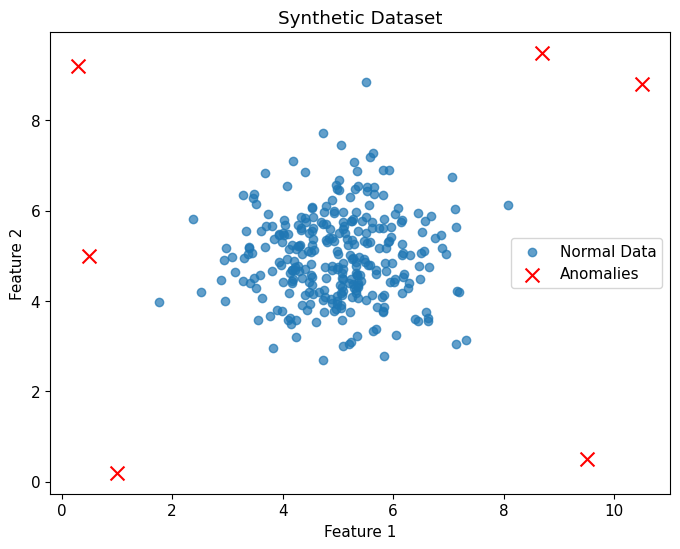

In [3]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_normal[:,0],
    X_normal[:,1],
    alpha=0.7,
    label="Normal Data"
)

plt.scatter(
    X_anomaly[:,0],
    X_anomaly[:,1],
    color="red",
    marker="x",
    s=100,
    label="Anomalies"
)

plt.title("Synthetic Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.show()

# 4.1 Exploratory Data Analysis

The scatter plot reveals a dense cluster of observations centered near the mean of the Gaussian distribution. These points represent the normal operating behavior of the system.

In contrast, the anomalous observations are located far from the central cluster. Because they occur in regions with relatively low data density, they are expected to receive much lower probability density values once the Gaussian model has been estimated.

Several important observations can already be made:

- The majority of observations are concentrated in a compact region.
- Anomalies are isolated from the primary data cluster.
- The separation between normal and anomalous observations suggests that a Gaussian model should perform well on this dataset.
- In real-world problems, anomalies are often much closer to the normal distribution, making detection considerably more challenging.

The next step is to estimate the parameters of the Gaussian distribution using only the normal training data.

# 5. Estimating Gaussian Parameters

The first computational step in Gaussian anomaly detection is estimating the parameters of the underlying distribution.

Given a dataset of normal observations,

$$
X =
\{x^{(1)},x^{(2)},\ldots,x^{(m)}\},
$$

our objective is to compute

$$
\mu
$$

and

$$
\sigma^2.
$$

For datasets containing multiple features, these quantities are estimated independently for each feature, resulting in a vector of means and a vector of variances.

Once these parameters have been estimated, they completely define the Gaussian model and enable probability density calculations for unseen observations.

In the following section, we implement this estimation procedure from scratch using NumPy.

In [4]:
def estimate_gaussian(X):
    """
    Estimate the parameters of a Gaussian distribution.

    Parameters
    ----------
    X : numpy.ndarray
        Dataset of shape (m, n), where m is the number of
        examples and n is the number of features.

    Returns
    -------
    mu : numpy.ndarray
        Mean of each feature.

    var : numpy.ndarray
        Variance of each feature.
    """

    # Compute the mean of each feature
    mu = np.mean(X, axis=0)

    # Compute the variance of each feature
    var = np.var(X, axis=0)

    return mu, var

In [5]:
mu, var = estimate_gaussian(X_normal)

print("Estimated Mean:\n", mu.round(2))
print()

print("Estimated Variance:\n", var.round(2))

Estimated Mean:
 [4.99 4.98]

Estimated Variance:
 [0.96 0.93]


# 6. Probability Density Estimation

Estimating the mean and variance allows us to describe the statistical behavior of the training data, but these parameters alone are not sufficient for anomaly detection. We also require a method to determine **how likely** a new observation is under the learned Gaussian model.

For an observation

$$
x=[x_1,x_2,\ldots,x_n],
$$

the Gaussian model assigns a probability density based on its distance from the estimated mean.

Assuming the features are statistically independent, the joint probability density is computed as the product of the individual feature densities,

$$
P(x)=\prod_{j=1}^{n}P(x_j;\mu_j,\sigma_j^2).
$$

Observations located near the center of the distribution receive relatively high probability densities, while observations far from the mean receive exponentially smaller values.

The probability density is therefore a quantitative measure of how well an observation conforms to the learned model of normal behavior. Low-density observations become candidates for anomaly detection. We implement this PDF directly using NumPy — the scipy import at the top is retained only to sanity-check our result against a reference implementation.

In [6]:
def multivariate_gaussian(X, mu, var):
    """
    Computes the probability density for each example
    assuming independent Gaussian features.

    Parameters
    ----------
    X   : numpy.ndarray of shape (m, n)
    mu  : numpy.ndarray of shape (n,)
    var : numpy.ndarray of shape (n,)

    Returns
    -------
    p : numpy.ndarray of shape (m,)
    """
    n = X.shape[1]
    diff = X - mu                          # (m, n) deviations from mean
    sigma_inv = np.diag(1 / var)          # diagonal precision matrix
    det_sigma = np.prod(var)              # determinant of diagonal cov = product of variances

    norm_const = 1 / (np.sqrt((2 * np.pi)**n * det_sigma))
    exponent = -0.5 * np.sum(diff @ sigma_inv * diff, axis=1)

    return norm_const * np.exp(exponent)

In [7]:
# Sanity check: our implementation should match scipy's output
from scipy.stats import multivariate_normal as sp_mvn

p_scratch = multivariate_gaussian(X_normal[:5], mu, var)
p_scipy   = sp_mvn(mean=mu, cov=np.diag(var)).pdf(X_normal[:5])

print("Our implementation: ", np.round(p_scratch, 8))
print("scipy reference:    ", np.round(p_scipy, 8))
print("Max absolute error: ", np.max(np.abs(p_scratch - p_scipy)))

Our implementation:  [0.14625019 0.03768259 0.16020536 0.03232442 0.12778306]
scipy reference:     [0.14625019 0.03768259 0.16020536 0.03232442 0.12778306]
Max absolute error:  6.938893903907228e-18


In [8]:
p = multivariate_gaussian(X, mu, var)

print(f"Maximum Probability Density : {np.max(p):.6f}")
print(f"Minimum Probability Density : {np.min(p):.6f}")
print(f"Average Probability Density : {np.mean(p):.6f}")

Maximum Probability Density : 0.168302
Minimum Probability Density : 0.000000
Average Probability Density : 0.082946


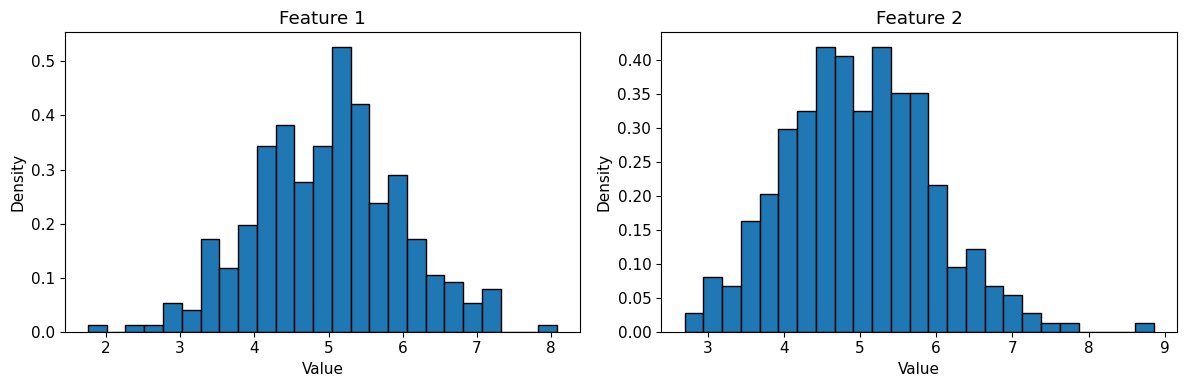

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    X_normal[:, 0],
    bins=25,
    density=True,
    edgecolor="black"
)
axes[0].set_title("Feature 1")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")

axes[1].hist(
    X_normal[:, 1],
    bins=25,
    density=True,
    edgecolor="black"
)
axes[1].set_title("Feature 2")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

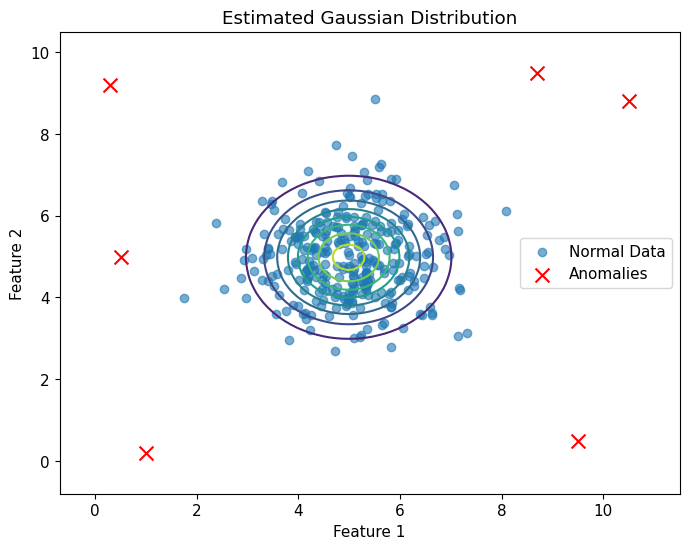

In [10]:
x = np.linspace(
    X[:, 0].min() - 1,
    X[:, 0].max() + 1,
    100
)

y = np.linspace(
    X[:, 1].min() - 1,
    X[:, 1].max() + 1,
    100
)

X1, X2 = np.meshgrid(x, y)

grid = np.column_stack((X1.ravel(), X2.ravel()))

Z = multivariate_gaussian(grid, mu, var)
Z = Z.reshape(X1.shape)

plt.figure(figsize=(8, 6))

plt.contour(
    X1,
    X2,
    Z,
    levels=10,
    cmap="viridis"
)

plt.scatter(
    X_normal[:, 0],
    X_normal[:, 1],
    alpha=0.6,
    label="Normal Data"
)

plt.scatter(
    X_anomaly[:, 0],
    X_anomaly[:, 1],
    color="red",
    marker="x",
    s=100,
    label="Anomalies"
)

plt.title("Estimated Gaussian Distribution")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.show()

# Interpretation of the Learned Distribution

The contour plot illustrates the probability density estimated by the Gaussian model. Each contour represents a region of equal probability density, with the innermost contours corresponding to the highest-density regions.

Several observations can be made:

- The highest probability densities occur near the estimated mean of the dataset.
- As the distance from the mean increases, the probability density decreases exponentially.
- The normal observations are concentrated within the high-density contours, indicating that they conform well to the learned Gaussian model.
- The anomalous observations lie outside the dense regions and therefore receive much lower probability densities.

This visualization provides an intuitive explanation of Gaussian anomaly detection. Rather than defining a hard geometric boundary, the model assigns each observation a probability density. A decision threshold, denoted by $$\varepsilon$$, is then used to separate statistically likely observations from unlikely ones.

In the following section, we determine this threshold automatically using a validation set and the F1 Score.

# 7. Threshold Selection

The Gaussian model assigns a probability density to every observation, but probability values alone do not determine whether an observation should be classified as normal or anomalous. A decision boundary is required.

Let $$\varepsilon$$ denote a threshold value. The classification rule is defined as

$$
P(x) < \varepsilon
\Longrightarrow
\text{Anomaly}
$$

$$
P(x) \geq \varepsilon
\Longrightarrow
\text{Normal}
$$

Choosing an appropriate threshold is crucial. An excessively small threshold may fail to identify genuine anomalies (false negatives), while an overly large threshold may incorrectly classify normal observations as anomalous (false positives).

Rather than selecting $$\varepsilon$$ manually, it is estimated using a **validation set** containing labeled examples. The optimal threshold is chosen by maximizing the **F1 Score**, which balances Precision and Recall.

# 7.1 Evaluation Metrics

To evaluate different threshold values, we use three standard classification metrics.

### Precision

Precision measures the proportion of predicted anomalies that are actually anomalous.

$$
\text{Precision}
=
\frac{TP}{TP+FP}
$$

---

### Recall

Recall measures the proportion of true anomalies that are successfully detected.

$$
\text{Recall}
=
\frac{TP}{TP+FN}
$$

---

### F1 Score

The F1 Score combines Precision and Recall into a single metric.

$$
F_1
=
\frac{2(\text{Precision})(\text{Recall})}
{\text{Precision}+\text{Recall}}
$$

where

- $TP$ = True Positives
- $FP$ = False Positives
- $FN$ = False Negatives

The threshold that produces the highest F1 Score is selected because it provides the best balance between identifying anomalies and minimizing false alarms.

In [11]:
# Validation data (normal examples)
X_val_normal = np.random.multivariate_normal(
    mean=[5, 5],
    cov=[[1, 0],
         [0, 1]],
    size=100
)

# Validation anomalies
X_val_anomaly = np.array([
    # Hard (close to boundary, ~2.5 sigma away)
    [7.5, 5.0],
    [5.0, 7.5],
    [7.2, 7.2],
    # Medium (~3.5 sigma away)
    [8.5, 5.0],
    [5.0, 8.5],
    # Easy (far from cluster)
    [10.0, 0.5],
    [0.5, 10.0],
])

# Combine validation set
X_val = np.vstack((X_val_normal, X_val_anomaly))

# Labels
# 0 -> Normal
# 1 -> Anomaly
y_val = np.hstack((
    np.zeros(len(X_val_normal)),
    np.ones(len(X_val_anomaly))
))

# Compute probability densities
p_val = multivariate_gaussian(X_val, mu, var)

In [12]:
def select_threshold(y_val, p_val):
    """
    Select the threshold that maximizes the F1 Score.
    """

    best_epsilon = 0
    best_f1 = 0

    step_size = (p_val.max() - p_val.min()) / 1000

    for epsilon in np.arange(p_val.min(), p_val.max(), step_size):

        predictions = (p_val < epsilon)

        tp = np.sum((predictions == 1) & (y_val == 1))
        fp = np.sum((predictions == 1) & (y_val == 0))
        fn = np.sum((predictions == 0) & (y_val == 1))

        precision = tp / (tp + fp) if (tp + fp) else 0
        recall = tp / (tp + fn) if (tp + fn) else 0

        if precision + recall == 0:
            f1 = 0
        else:
            f1 = (2 * precision * recall) / (precision + recall)

        if f1 > best_f1:
            best_f1 = f1
            best_epsilon = epsilon

    return best_epsilon, best_f1

In [13]:
epsilon, best_f1 = select_threshold(y_val, p_val)

print(f"Optimal Threshold (ε): {epsilon:.8f}")
print(f"Best F1 Score: {best_f1:.4f}")

Optimal Threshold (ε): 0.00101176
Best F1 Score: 0.8333


In [14]:
# Final evaluation at optimal threshold
predictions_opt = (p_val < epsilon).astype(int)

tp = np.sum((predictions_opt == 1) & (y_val == 1))
fp = np.sum((predictions_opt == 1) & (y_val == 0))
fn = np.sum((predictions_opt == 0) & (y_val == 1))
tn = np.sum((predictions_opt == 0) & (y_val == 0))

precision = tp / (tp + fp) if (tp + fp) else 0
recall    = tp / (tp + fn) if (tp + fn) else 0
f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0

print("Final Evaluation at Optimal Threshold")
print("=" * 40)
print(f"True Positives  (TP) : {int(tp)}")
print(f"False Positives (FP) : {int(fp)}")
print(f"False Negatives (FN) : {int(fn)}")
print(f"True Negatives  (TN) : {int(tn)}")
print()
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Final Evaluation at Optimal Threshold
True Positives  (TP) : 5
False Positives (FP) : 0
False Negatives (FN) : 2
True Negatives  (TN) : 100

Precision : 1.0000
Recall    : 0.7143
F1 Score  : 0.8333


In [15]:
thresholds = {
    "Smaller Threshold (ε / 5)": epsilon / 5,
    "Optimal Threshold (ε)": epsilon,
    "Larger Threshold (5 × ε)": epsilon * 5
}

print(f"{'Threshold':<30} {'Detected':<12} {'Precision':<12} {'Recall':<12} {'F1'}")
print("-" * 70)

for label, threshold in thresholds.items():
    predictions = (p_val < threshold).astype(int)

    tp = np.sum((predictions == 1) & (y_val == 1))
    fp = np.sum((predictions == 1) & (y_val == 0))
    fn = np.sum((predictions == 0) & (y_val == 1))

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall    = tp / (tp + fn) if (tp + fn) else 0
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0

    print(f"{label:<30} {int(np.sum(predictions)):<12} {precision:<12.4f} {recall:<12.4f} {f1:.4f}")

Threshold                      Detected     Precision    Recall       F1
----------------------------------------------------------------------
Smaller Threshold (ε / 5)      2            1.0000       0.2857       0.4444
Optimal Threshold (ε)          5            1.0000       0.7143       0.8333
Larger Threshold (5 × ε)       9            0.5556       0.7143       0.6250


# 8. Discussion

The experiment demonstrates how the decision threshold directly influences the behavior of the anomaly detection model.

Several observations can be made:

- A **smaller threshold** is more conservative, classifying only observations with extremely low probability densities as anomalies. This typically increases Precision but may reduce Recall by missing subtle anomalies.

- The **optimal threshold**, selected using the validation set, provides the best balance between Precision and Recall, resulting in the highest F1 Score.

- A **larger threshold** classifies more observations as anomalous. Although this increases Recall, it may also introduce additional False Positives, reducing Precision.

This experiment highlights that anomaly detection is not solely a statistical modeling problem. Even with an accurate Gaussian model, the final performance depends heavily on selecting an appropriate decision threshold.

In practical applications, threshold selection should always be guided by validation data and the relative costs of False Positives and False Negatives.

# 9. Limitations and Future Directions

Although Gaussian anomaly detection is one of the most intuitive statistical approaches for identifying unusual observations, its effectiveness depends on several underlying assumptions.

## Limitations

### 1. Gaussian Assumption

The algorithm assumes that the normal data approximately follows a Gaussian (normal) distribution. If the true distribution is highly skewed, multimodal, or non-Gaussian, the estimated probability densities may be inaccurate, leading to poor anomaly detection performance.

### 2. Independent Features

In this notebook, each feature is modeled independently using a diagonal covariance matrix. While this simplifies computation, it ignores correlations between features. In many real-world datasets, feature dependencies carry valuable information that can improve anomaly detection.

### 3. Sensitivity to Outliers

Because the Gaussian parameters are estimated directly from the training data, the presence of anomalous observations during training can distort the estimated mean and variance, reducing the model's effectiveness.

### 4. High-Dimensional Data

As the number of features increases, accurately estimating probability densities becomes increasingly difficult due to the **curse of dimensionality**. Statistical models often require substantially more data to remain reliable in high-dimensional spaces.

---

## Future Directions

Several modern anomaly detection techniques address these limitations by relaxing Gaussian assumptions or learning more expressive representations of normal behavior.

Some widely used alternatives include:

- **Isolation Forest** – isolates anomalies through recursive random partitioning.
- **One-Class Support Vector Machine (OC-SVM)** – learns a decision boundary surrounding normal observations.
- **Local Outlier Factor (LOF)** – detects observations with unusually low local density.
- **Autoencoders** – neural networks that identify anomalies using reconstruction error.
- **Deep SVDD** – learns compact representations of normal data using deep learning.

These methods generally perform better on complex, high-dimensional, and non-linear datasets, making them popular choices in modern anomaly detection research.

# 10. Conclusion

In this notebook, we developed a complete Gaussian-based anomaly detection system from first principles, emphasizing both the statistical foundations and practical implementation of the algorithm.

The workflow consisted of:

1. Formulating anomaly detection as a probability estimation problem.
2. Modeling normal observations using Gaussian distributions.
3. Estimating the distribution parameters through Maximum Likelihood Estimation (MLE).
4. Computing probability densities for unseen observations.
5. Selecting an optimal decision threshold using Precision, Recall, and the F1 Score.
6. Detecting anomalies based on their statistical likelihood.
7. Evaluating how threshold selection influences detection performance.

The experiments demonstrated that observations located in low-probability regions of the learned Gaussian distribution can be effectively identified as anomalies. Furthermore, the threshold sensitivity analysis illustrated the trade-off between detecting more anomalies and minimizing false alarms, highlighting the importance of selecting an appropriate decision threshold.

While Gaussian anomaly detection is computationally efficient and mathematically interpretable, it is most effective when its underlying assumptions are satisfied. As datasets become larger, noisier, and more complex, more advanced techniques may provide improved performance.

Nevertheless, Gaussian anomaly detection remains an important foundational algorithm, offering valuable insight into the probabilistic principles that underpin many modern anomaly detection methods.